# Preparação dos dados
_Feature Engineering_

---

## Sumário

1. **Importação de bibliotecas**
2. **Carregamento das bases**
3. **Feature Engineering**
    - 3.1. Features criadas na construção da ABT (ETL)
    - 3.2. Criando novas features
    - 3.3. Análise de correlação das features numéricas
4. **Salvando os DataFrames em formato parquet**

<br>

---

<br>

## 1. Importação de bibliotecas

In [196]:
# Importação de pacotes e definição de parâmetros globais

import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import warnings
import gc

from pathlib import Path

In [197]:
# Configuração de parâmetros globais

# Configurar para exibir todas as colunas do Dataframe
pd.set_option('display.max_columns', None)

# Configurar para exibir o conteúdo completo das colunas
pd.set_option('display.max_colwidth', None)

# Ignorar warnings para uma execução mais limpa
warnings.filterwarnings('ignore')

## 2. Carregamento das bases

In [198]:
# Efetuando a limpeza da memória antes do carregamento dos dados
print(f'\nQuantidade de objetos removidos da memória: {gc.collect()}')


Quantidade de objetos removidos da memória: 59


In [199]:
# Caminho para o diretório de dados
DATA_DIR = Path('../data/processed')

# Carregando os dados
try:
    table = pq.read_table(DATA_DIR)
    df = table.to_pandas()
except Exception as e:
    print(f'Erro ao carregar os dados: {e}')

In [200]:
print('VOLUMETRIA')
print(f'Quantidade de linhas (registros):  {df.shape[0]:,}')
print(f'Quantidade de colunas (variáveis): {df.shape[1]:,}')

VOLUMETRIA
Quantidade de linhas (registros):  10,000
Quantidade de colunas (variáveis): 24


In [201]:
df.head(10)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,age_bucket,tenure_bucket,balance_to_salary_ratio,products_per_tenure,is_high_credit_score,is_senior_new_customer,avg_salary_by_geography,customer_count_by_geography,is_zero_balance,is_multi_product_customer,is_active_with_card,Exited,processing_date
0,15565714,601,France,Male,47,1,64430.06,2,0,1,96517.97,Adult,New customer,0.667545,2.000000,0,0,99899.180814,5014,0,1,0,0,2026-04-01
1,15565806,532,France,Male,38,9,0.00,2,0,0,30583.95,Adult,Long term,0.000000,0.222222,0,0,99899.180814,5014,1,1,0,0,2026-04-01
2,15565879,845,France,Female,28,9,0.00,2,1,1,56185.98,Young,Long term,0.000000,0.222222,1,0,99899.180814,5014,1,1,1,0,2026-04-01
3,15565891,709,France,Male,39,8,0.00,2,1,0,56214.09,Adult,Long term,0.000000,0.250000,0,0,99899.180814,5014,1,1,0,0,2026-04-01
4,15565996,653,France,Male,44,8,0.00,2,1,1,154639.72,Adult,Long term,0.000000,0.250000,0,0,99899.180814,5014,1,1,1,0,2026-04-01
5,15566111,596,France,Male,39,9,0.00,1,1,0,48963.59,Adult,Long term,0.000000,0.111111,0,0,99899.180814,5014,1,0,0,0,2026-04-01
6,15566139,526,France,Female,37,5,53573.18,1,1,0,62830.97,Adult,Mid tenure,0.852656,0.200000,0,0,99899.180814,5014,0,0,0,0,2026-04-01
7,15566251,618,France,Female,37,5,96652.86,1,1,0,98686.40,Adult,Mid tenure,0.979394,0.200000,0,0,99899.180814,5014,0,0,0,1,2026-04-01
8,15566269,787,France,Male,25,5,0.00,2,1,0,47307.90,Young,Mid tenure,0.000000,0.400000,1,0,99899.180814,5014,1,1,0,0,2026-04-01
9,15566295,761,France,Female,33,6,138053.79,2,1,0,148779.41,Adult,Mid tenure,0.927909,0.333333,1,0,99899.180814,5014,0,1,0,0,2026-04-01


In [202]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CustomerId                   10000 non-null  int32   
 1   CreditScore                  10000 non-null  int32   
 2   Geography                    10000 non-null  str     
 3   Gender                       10000 non-null  str     
 4   Age                          10000 non-null  int32   
 5   Tenure                       10000 non-null  int32   
 6   Balance                      10000 non-null  float64 
 7   NumOfProducts                10000 non-null  int32   
 8   HasCrCard                    10000 non-null  int32   
 9   IsActiveMember               10000 non-null  int32   
 10  EstimatedSalary              10000 non-null  float64 
 11  age_bucket                   10000 non-null  str     
 12  tenure_bucket                10000 non-null  str     
 13  balance_to_sa

In [203]:
# Preenchendo os valores nulos da variável 'products_per_tenure' com o valor da variável 'NumOfProducts'
df['products_per_tenure'] = df['products_per_tenure'].fillna(df['NumOfProducts'])

## 3. Feature Engineering

### 3.1. Features criadas na construção da ABT (ETL)

In [204]:
# age_bucket - categorização da idade em faixas etárias, para capturar padrões de comportamento 
# relacionados a diferentes grupos de idade

df_temp = df[['CustomerId', 'Age', 'age_bucket']]
df_temp.groupby('age_bucket').sample(1)

,CustomerId,Age,age_bucket
2156,15620936,32,Adult
1276,15597914,51,Senior
7267,15748481,27,Young


In [205]:
# tenure_bucket - categorização do tempo de relacionamento com o banco em faixas, para identificar 
# padrões de comportamento relacionados à duração do relacionamento

df_temp = df[['CustomerId', 'Tenure', 'tenure_bucket']]
df_temp.groupby('tenure_bucket').sample(1)

,CustomerId,Tenure,tenure_bucket
3680,15657957,8,Long term
1040,15591344,6,Mid tenure
4986,15689633,2,New customer


In [206]:
# balance_to_salary_ratio - relação entre o saldo do cliente e seu salário estimado, para capturar a 
# proporção do saldo em relação à capacidade financeira do cliente

df_temp = df[['CustomerId', 'Tenure', 'EstimatedSalary', 'balance_to_salary_ratio']]
df_temp.groupby('balance_to_salary_ratio')
df_temp.head(5)

,CustomerId,Tenure,EstimatedSalary,balance_to_salary_ratio
0,15565714,1,96517.97,0.667545
1,15565806,9,30583.95,0.000000
2,15565879,9,56185.98,0.000000
3,15565891,8,56214.09,0.000000
4,15565996,8,154639.72,0.000000


In [207]:
# products_per_tenure - relação entre o número de produtos contratados e o tempo de relacionamento com o 
# banco, para identificar clientes que possuem poucos produtos em relação ao tempo que estão com o banco, 
# o que pode indicar baixo engajamento e potencial risco de churn

df_temp = df[['CustomerId', 'NumOfProducts', 'Tenure', 'products_per_tenure']]
df_temp.groupby('products_per_tenure')
df_temp.head(5)

,CustomerId,NumOfProducts,Tenure,products_per_tenure
0,15565714,2,1,2.000000
1,15565806,2,9,0.222222
2,15565879,2,9,0.222222
3,15565891,2,8,0.250000
4,15565996,2,8,0.250000


In [208]:
# is_high_credit_score - indicador de score de crédito alto, para identificar clientes com score de crédito 
# acima de um determinado limiar, o que pode indicar menor risco de churn devido à melhor saúde financeira

df_temp = df[['CustomerId', 'CreditScore', 'is_high_credit_score']]
df_temp.groupby('is_high_credit_score').sample(1)

,CustomerId,CreditScore,is_high_credit_score
5703,15708513,446,0
7671,15757931,804,1


In [209]:
# is_senior_new_customer - indicador de clientes idosos e novos, para identificar clientes com idade acima de 
# 60 anos e tempo de relacionamento com o banco inferior a 2 anos, o que pode indicar um grupo de clientes 
# mais vulnerável ao churn devido à combinação de idade avançada e falta de vínculo sólido com o banco

df_temp = df[['CustomerId', 'Age', 'Tenure', 'is_senior_new_customer']]
df_temp.groupby('is_senior_new_customer').sample(1)

,CustomerId,Age,Tenure,is_senior_new_customer
9101,15793247,34,5,0
383,15576094,71,0,1


In [210]:
# avg_salary_by_geography - salário médio por região geográfica, para capturar diferenças regionais na 
# capacidade financeira dos clientes, o que pode influenciar o comportamento de churn

df_temp = df[['CustomerId', 'EstimatedSalary', 'Geography', 'avg_salary_by_geography']]
df_temp.groupby('avg_salary_by_geography').sample(1)

,CustomerId,EstimatedSalary,Geography,avg_salary_by_geography
3944,15664521,104533.51,Spain,99440.572281
6002,15715745,49599.27,France,99899.180814
3689,15658716,178106.34,Germany,101113.435102


In [211]:
# customer_count_by_geography - contagem de clientes por região geográfica, para identificar regiões com 
# maior concentração de clientes

df_temp = df[['CustomerId', 'Geography', 'customer_count_by_geography']]
df_temp.groupby('customer_count_by_geography').sample(1)

,CustomerId,Geography,customer_count_by_geography
9844,15811594,Spain,2477
2176,15620836,Germany,2509
9169,15795224,France,5014


In [212]:
# is_zero_balance - indicador de saldo zero, para identificar clientes que possuem saldo zero em suas contas, 
# o que pode indicar falta de engajamento e potencial risco de churn

df_temp = df[['CustomerId', 'Balance', 'is_zero_balance']]
df_temp.groupby('is_zero_balance').sample(1)

,CustomerId,Balance,is_zero_balance
9628,15806230,121647.54,0
4221,15671915,0.00,1


In [213]:
# is_multi_product_customer - indicador de cliente com múltiplos produtos, para identificar clientes que 
# possuem mais de um produto contratado, o que pode indicar maior engajamento e menor risco de churn

df_temp = df[['CustomerId', 'NumOfProducts', 'is_multi_product_customer']]
df_temp.groupby('is_multi_product_customer').sample(1)

,CustomerId,NumOfProducts,is_multi_product_customer
8371,15775293,1,0
9176,15794849,2,1


In [214]:
# is_active_with_card - indicador de cliente ativo com cartão de crédito, para identificar clientes que são ativos
# e possuem cartão de crédito, o que pode indicar um grupo de clientes mais engajados e com menor risco de churn

df_temp = df[['CustomerId', 'IsActiveMember', 'HasCrCard', 'is_active_with_card']]
df_temp.groupby('is_active_with_card').sample(1)

,CustomerId,IsActiveMember,HasCrCard,is_active_with_card
9350,15799515,0,1,0
2876,15637717,1,1,1


### 3.2. Criando nova features

In [215]:
# balance_zscore_geo - z-score do saldo por região geográfica, para identificar clientes com saldo significativamente 
# diferente da média de sua região, o que pode indicar comportamento atípico e potencial risco de churn

df['balance_zscore_geo'] = (
    df['Balance'] - df.groupby('Geography')['Balance'].transform('mean')
) / df.groupby('Geography')['Balance'].transform('std')

df_temp = df[['CustomerId', 'Balance', 'Geography', 'balance_zscore_geo']]
df_temp.groupby('balance_zscore_geo').sample(1)

,CustomerId,Balance,Geography,balance_zscore_geo
4334,15674156,27288.43,Germany,-3.420978
5984,15715638,27517.15,Germany,-3.412514
2481,15627830,32197.64,Germany,-3.239303
9332,15798964,35016.60,Germany,-3.134982
7423,15751032,35549.81,Germany,-3.115250
...,...,...,...,...
3920,15663888,204017.40,Germany,3.119209
7178,15745433,205770.78,Germany,3.184096
9183,15795298,206868.78,Germany,3.224730
2133,15620268,212696.32,Germany,3.440389


In [216]:
# salary_zscore_geo - z-score do salário por região geográfica, para identificar clientes com salário significativamente
# diferente da média de sua região, o que pode indicar comportamento atípico e potencial risco

df['salary_zscore_geo'] = (
    df['EstimatedSalary'] - df.groupby('Geography')['EstimatedSalary'].transform('mean')
) / df.groupby('Geography')['EstimatedSalary'].transform('std')

df_temp = df[['CustomerId', 'EstimatedSalary', 'Geography', 'salary_zscore_geo']]
df_temp.groupby('salary_zscore_geo').sample(1)

,CustomerId,EstimatedSalary,Geography,salary_zscore_geo
4523,15679693,90.07,France,-1.740767
2921,15639662,96.27,France,-1.740659
1451,15602851,106.67,France,-1.740477
2254,15623369,123.07,France,-1.740191
3302,15648735,142.81,France,-1.739847
...,...,...,...,...
798,15585961,199505.53,Spain,1.752338
7897,15763065,199753.97,Spain,1.756689
4696,15682834,199857.47,Spain,1.758501
5289,15697270,199953.33,Spain,1.760180


In [217]:
# relationship_strength - indicador de força do relacionamento com o banco, baseado em número de produtos,
# tempo de relacionamento e atividade do cliente

df['relationship_strength'] = (
    df['NumOfProducts'] * 2 +
    df['Tenure'] * 0.5 +
    df['IsActiveMember'] * 3
)

df_temp = df[['CustomerId', 'NumOfProducts', 'Tenure', 'IsActiveMember', 'relationship_strength']]
df_temp.groupby('relationship_strength').sample(1)

,CustomerId,NumOfProducts,Tenure,IsActiveMember,relationship_strength
9283,15797960,1,0,0,2.0
3483,15653937,1,1,0,2.5
9114,15793842,1,2,0,3.0
2610,15631800,1,3,0,3.5
9471,15801904,2,0,0,4.0
7513,15754105,1,5,0,4.5
6139,15718454,2,2,0,5.0
1872,15613699,1,7,0,5.5
5383,15699523,2,4,0,6.0
6391,15724663,2,5,0,6.5


In [218]:
# credit_balance_interaction - interação entre score de crédito e saldo, para capturar a combinação de saúde 
# financeira e engajamento do cliente

df['credit_balance_interaction'] = df['CreditScore'] * df['Balance']

df_temp = df[['CustomerId', 'CreditScore', 'Balance', 'credit_balance_interaction']]
df_temp.groupby('credit_balance_interaction').sample(1)

,CustomerId,CreditScore,Balance,credit_balance_interaction
6851,15736769,663,0.00,0.000000e+00
9614,15806771,753,3768.69,2.837824e+06
5943,15713774,644,12459.19,8.023718e+06
8447,15776467,702,14262.80,1.001249e+07
7015,15741416,707,16893.59,1.194377e+07
...,...,...,...,...
5949,15714241,749,222267.63,1.664785e+08
6890,15737509,850,199229.14,1.693448e+08
1643,15607275,850,206014.94,1.751127e+08
4210,15671256,850,211774.31,1.800082e+08


In [219]:
# credit_products_interaction - interação entre score de crédito e número de produtos, para capturar a combinação
# de saúde financeira e engajamento do cliente

df['credit_products_interaction'] = df['CreditScore'] * df['NumOfProducts']

df_temp = df[['CustomerId', 'CreditScore', 'NumOfProducts', 'credit_products_interaction']]
df_temp.groupby('credit_products_interaction').sample(1)

,CustomerId,CreditScore,NumOfProducts,credit_products_interaction
9501,15803202,350,1,350
4533,15679249,351,1,351
1850,15612494,359,1,359
1274,15597896,365,1,365
9047,15791533,367,1,367
...,...,...,...,...
8764,15784958,797,4,3188
4182,15670374,819,4,3276
4306,15673591,842,4,3368
2228,15622033,847,4,3388


In [220]:
# products_per_year - relação entre o número de produtos contratados e o tempo de relacionamento com o banco em 
# anos, para identificar clientes que possuem poucos produtos em relação ao tempo que estão com o banco, o que 
# pode indicar baixo engajamento e potencial risco de churn

df['products_per_year'] = df['NumOfProducts'] / (df['Tenure'] + 1)

df_temp = df[['CustomerId', 'NumOfProducts', 'Tenure', 'products_per_year']]
df_temp.groupby('products_per_year').sample(1)

,CustomerId,NumOfProducts,Tenure,products_per_year
6506,15728078,1,10,0.090909
7561,15755405,1,9,0.100000
183,15570289,1,8,0.111111
7414,15751628,1,7,0.125000
2552,15630195,1,6,0.142857
7991,15765257,1,5,0.166667
1892,15612776,2,10,0.181818
9924,15813132,1,4,0.200000
9753,15809722,2,8,0.222222
8357,15774857,2,7,0.250000


In [221]:
# balance_per_product - relação entre o saldo do cliente e o número de produtos contratados, para identificar 
# clientes que possuem um saldo alto em relação ao número de produtos, o que pode indicar um grupo de clientes 
# com maior potencial de churn devido à falta de diversificação em seus produtos financeiros

df['balance_per_product'] = df['Balance'] / (df['NumOfProducts'] + 1)

df_temp = df[['CustomerId', 'Balance', 'NumOfProducts', 'balance_per_product']]
df_temp.groupby('balance_per_product').sample(1)

,CustomerId,Balance,NumOfProducts,balance_per_product
7707,15758513,0.00,2,0.000000
9614,15806771,3768.69,2,1256.230000
8447,15776467,14262.80,2,4754.266667
5943,15713774,12459.19,1,6229.595000
7015,15741416,16893.59,1,8446.795000
...,...,...,...,...
1142,15594408,213146.20,1,106573.100000
842,15586674,216109.88,1,108054.940000
247,15571958,221532.80,1,110766.400000
5949,15714241,222267.63,1,111133.815000


In [222]:
# salary_per_product - relação entre o salário estimado e o número de produtos contratados, para identificar 
# clientes com maior potencial de churn devido à falta de diversificação em seus produtos financeiros    

df['salary_per_product'] = df['EstimatedSalary'] / (df['NumOfProducts'] + 1)

df_temp = df[['CustomerId', 'EstimatedSalary', 'NumOfProducts', 'salary_per_product']]
df_temp.groupby('salary_per_product').sample(1)

,CustomerId,EstimatedSalary,NumOfProducts,salary_per_product
9030,15791053,11.58,1,5.790000
4523,15679693,90.07,2,30.023333
8836,15786463,91.75,2,30.583333
2921,15639662,96.27,2,32.090000
3302,15648735,142.81,2,47.603333
...,...,...,...,...
9523,15804211,199841.32,1,99920.660000
7017,15741719,199862.75,1,99931.375000
7856,15762331,199929.17,1,99964.585000
5289,15697270,199953.33,1,99976.665000


In [223]:
# engagement_index - índice de engajamento do cliente, baseado em atividade, número de produtos e posse de 
# cartão de crédito, para identificar clientes mais engajados e com menor risco de churn

df['engagement_index'] = (
    df['IsActiveMember'] * 2 +
    df['NumOfProducts'] +
    df['HasCrCard']
)

df_temp = df[['CustomerId', 'IsActiveMember', 'NumOfProducts', 'HasCrCard', 'engagement_index']]
df_temp.groupby('engagement_index').sample(1)

,CustomerId,IsActiveMember,NumOfProducts,HasCrCard,engagement_index
5159,15694860,0,1,0,1
4789,15684696,0,1,1,2
8174,15769948,1,1,0,3
9005,15791191,1,1,1,4
9764,15810227,1,2,1,5
9873,15812230,1,3,1,6
9866,15812888,1,4,1,7


In [224]:
# inactivity_risk_flag - indicador de risco de inatividade, para identificar clientes que são inativos 
# (IsActiveMember = 0) e possuem saldo positivo, o que pode indicar um grupo de clientes com maior risco 
# de churn devido à falta de engajamento

df['inactivity_risk_flag'] = (
    (df['IsActiveMember'] == 0) & (df['Balance'] > 0)
).astype(int)

df_temp = df[['CustomerId', 'IsActiveMember', 'Balance', 'inactivity_risk_flag']]
df_temp.groupby('inactivity_risk_flag').sample(1)

,CustomerId,IsActiveMember,Balance,inactivity_risk_flag
2453,15627412,0,0.00,0
4955,15690130,0,137649.47,1


In [225]:
# low_relationship_customer - indicador de cliente com baixo relacionamento, para identificar clientes que 
# possuem apenas um produto contratado, o que pode indicar baixo engajamento e potencial risco de churn

df['low_relationship_customer'] = (df['NumOfProducts'] == 1).astype(int)

df_temp = df[['CustomerId', 'NumOfProducts', 'low_relationship_customer']]
df_temp.groupby('low_relationship_customer').sample(1)

,CustomerId,NumOfProducts,low_relationship_customer
7235,15746410,2,0
1445,15602479,1,1


In [226]:
# high_value_customer - indicador de cliente de alto valor, para identificar clientes que possuem um saldo acima 
# do terceiro quartil, o que pode indicar um grupo de clientes com maior potencial de churn devido ao valor 
# financeiro que representam para o banco

p75_balance = df['Balance'].quantile(0.75)
df['high_value_customer'] = (df['Balance'] > p75_balance).astype(int)

df_temp = df[['CustomerId', 'Balance', 'high_value_customer']]
df_temp.groupby('high_value_customer').sample(1)

,CustomerId,Balance,high_value_customer
6355,15724444,125877.65,0
5578,15705298,172693.54,1


In [227]:
# balance_vs_geo_avg - relação entre o saldo do cliente e a média de saldo de sua região geográfica, para 
# identificar clientes que possuem um saldo significativamente diferente da média de sua região

geo_avg_balance = df.groupby('Geography')['Balance'].transform('mean')
df['balance_vs_geo_avg'] = df['Balance'] / (geo_avg_balance + 1)

df_temp = df[['CustomerId', 'Balance', 'Geography', 'balance_vs_geo_avg']]
df_temp.groupby('balance_vs_geo_avg').sample(1)

,CustomerId,Balance,Geography,balance_vs_geo_avg
3903,15663885,0.00,France,0.000000
9614,15806771,3768.69,France,0.060694
5943,15713774,12459.19,Spain,0.201543
4334,15674156,27288.43,Germany,0.227914
5984,15715638,27517.15,Germany,0.229825
...,...,...,...,...
842,15586674,216109.88,Spain,3.495840
247,15571958,221532.80,Spain,3.583563
5949,15714241,222267.63,Spain,3.595450
5970,15715622,238387.56,France,3.839162


In [228]:
# salary_vs_geo_avg - relação entre o salário do cliente e a média de salário de sua região geográfica, para 
# identificar clientes que possuem um salário significativamente diferente da média de sua região

geo_avg_salary = df.groupby('Geography')['EstimatedSalary'].transform('mean')
df['salary_vs_geo_avg'] = df['EstimatedSalary'] / (geo_avg_salary + 1)

df_temp = df[['CustomerId', 'EstimatedSalary', 'Geography', 'salary_vs_geo_avg']]
df_temp.groupby('salary_vs_geo_avg').sample(1)

,CustomerId,EstimatedSalary,Geography,salary_vs_geo_avg
9030,15791053,11.58,Germany,0.000115
4523,15679693,90.07,France,0.000902
8836,15786463,91.75,Germany,0.000907
2921,15639662,96.27,France,0.000964
1451,15602851,106.67,France,0.001068
...,...,...,...,...
798,15585961,199505.53,Spain,2.006259
7897,15763065,199753.97,Spain,2.008757
4696,15682834,199857.47,Spain,2.009798
5289,15697270,199953.33,Spain,2.010762


In [229]:
# credit_score_vs_geo_avg - relação entre o score de crédito do cliente e a média de score de crédito de sua região geográfica, para
# identificar clientes que possuem um score de crédito significativamente diferente da média de sua região 

geo_avg_credit = df.groupby('Geography')['CreditScore'].transform('mean')
df['credit_score_vs_geo_avg'] = df['CreditScore'] / (geo_avg_credit + 1)

df_temp = df[['CustomerId', 'CreditScore', 'Geography', 'credit_score_vs_geo_avg']]
df_temp.groupby('credit_score_vs_geo_avg').sample(1)

,CustomerId,CreditScore,Geography,credit_score_vs_geo_avg
7732,15758813,350,Germany,0.536437
4796,15685372,350,Spain,0.536535
7962,15765173,350,France,0.537908
4533,15679249,351,Germany,0.537969
5092,15692416,358,Spain,0.548799
...,...,...,...,...
9500,15803121,847,France,1.301738
9036,15791373,850,Germany,1.302775
288,15572390,850,Spain,1.303014
6951,15739160,849,France,1.304812


In [230]:
# high_balance_inactive - indicador de clientes inativos com saldo alto, para identificar clientes que possuem 
# um saldo acima do terceiro quartil e não são ativos, o que pode indicar um grupo de clientes com maior potencial 
# de churn devido à combinação de alto valor financeiro e falta de engajamento

threshold = df['Balance'].quantile(0.75)
df['high_balance_inactive'] = (
    (df['Balance'] > threshold) & (df['IsActiveMember'] == 0)
).astype(int)

df_temp = df[['CustomerId', 'Balance', 'IsActiveMember', 'high_balance_inactive']]
df_temp.groupby('high_balance_inactive').sample(1)

,CustomerId,Balance,IsActiveMember,high_balance_inactive
4875,15687491,101207.75,0,0
761,15585823,128131.73,0,1


In [231]:
# high_value_low_products - indicador de clientes de alto valor com baixo número de produtos, para identificar 
# clientes que possuem um saldo acima do terceiro quartil e apenas um produto contratado, o que pode indicar 
# um grupo de clientes com maior potencial de churn devido à falta de diversificação em seus produtos financeiros

df['high_value_low_products'] = (
    (df['Balance'] > threshold) & (df['NumOfProducts'] == 1)
).astype(int)

df_temp = df[['CustomerId', 'Balance', 'NumOfProducts', 'high_value_low_products']]
df_temp.groupby('high_value_low_products').sample(1)

,CustomerId,Balance,NumOfProducts,high_value_low_products
5914,15713890,0.00,2,0
1801,15611371,176134.54,1,1


In [232]:
# senior_high_balance - indicador de clientes idosos com saldo alto, para identificar clientes com idade acima 
# de 50 anos e saldo acima da mediana, o que pode indicar um grupo de clientes com maior potencial de churn 
# devido à combinação de idade avançada e alto valor financeiro  

median_balance = df['Balance'].median()
df['senior_high_balance'] = (
    (df['Age'] > 50) & (df['Balance'] > median_balance)
).astype(int)

df_temp = df[['CustomerId', 'Age', 'Balance', 'senior_high_balance']]
df_temp.groupby('senior_high_balance').sample(1)

,CustomerId,Age,Balance,senior_high_balance
7642,15756871,39,0.00,0
3077,15642391,51,109978.83,1


In [233]:
# inactive_high_salary - indicador de clientes inativos com salário alto, para identificar clientes que possuem um salário acima do terceiro 
# quartil e não são ativos, o que pode indicar um grupo de clientes com maior potencial de churn devido à combinação de alta capacidade 
# financeira e falta de engajamento

df['inactive_high_salary'] = (
    (df['IsActiveMember'] == 0) &
    (df['EstimatedSalary'] > df['EstimatedSalary'].quantile(0.75))
).astype(int)

df_temp = df[['CustomerId', 'IsActiveMember', 'EstimatedSalary', 'inactive_high_salary']]
df_temp.groupby('inactive_high_salary').sample(1)

,CustomerId,IsActiveMember,EstimatedSalary,inactive_high_salary
282,15573452,0,19862.78,0
1370,15600934,0,171189.83,1


In [234]:
# inactive_multi_product - indicador de clientes inativos com múltiplos produtos, para identificar clientes que são inativos e possuem mais 
# de um produto contratado, o que pode indicar um grupo de clientes com maior potencial de churn devido à falta de engajamento apesar de 
# possuir múltiplos produtos financeiros   

df['inactive_multi_product'] = (
    (df['IsActiveMember'] == 0) &
    (df['NumOfProducts'] > 1)
).astype(int)

df_temp = df[['CustomerId', 'IsActiveMember', 'NumOfProducts', 'inactive_multi_product']]
df_temp.groupby('inactive_multi_product').sample(1)

,CustomerId,IsActiveMember,NumOfProducts,inactive_multi_product
2604,15631481,1,2,0
3247,15646942,0,2,1


In [235]:
# inactive_long_term_customer - indicador de clientes inativos com longo tempo de relacionamento, para identificar clientes que são inativos 
# e possuem um tempo de relacionamento com o banco acima do terceiro quartil, o que pode indicar um grupo de clientes com maior potencial de 
# churn devido à falta de engajamento apesar de um vínculo sólido com o banco     

df['inactive_long_term_customer'] = (
    (df['IsActiveMember'] == 0) &
    (df['Tenure'] > df['Tenure'].quantile(0.75))
).astype(int)

df_temp = df[['CustomerId', 'IsActiveMember', 'Tenure', 'inactive_long_term_customer']]
df_temp.groupby('inactive_long_term_customer').sample(1)

,CustomerId,IsActiveMember,Tenure,inactive_long_term_customer
1471,15603764,1,4,0
357,15575147,0,9,1


### 3.3. Análise de correlação das features numéricas

In [236]:
df.head(10)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,age_bucket,tenure_bucket,balance_to_salary_ratio,products_per_tenure,is_high_credit_score,is_senior_new_customer,avg_salary_by_geography,customer_count_by_geography,is_zero_balance,is_multi_product_customer,is_active_with_card,Exited,processing_date,balance_zscore_geo,salary_zscore_geo,relationship_strength,credit_balance_interaction,credit_products_interaction,products_per_year,balance_per_product,salary_per_product,engagement_index,inactivity_risk_flag,low_relationship_customer,high_value_customer,balance_vs_geo_avg,salary_vs_geo_avg,credit_score_vs_geo_avg,high_balance_inactive,high_value_low_products,senior_high_balance,inactive_high_salary,inactive_multi_product,inactive_long_term_customer
0,15565714,601,France,Male,47,1,64430.06,2,0,1,96517.97,Adult,New customer,0.667545,2.000000,0,0,99899.180814,5014,0,1,0,0,2026-04-01,0.036446,-0.058972,7.5,3.872247e+07,1202,1.000000,21476.686667,32172.656667,4,0,0,0,1.037627,0.966144,0.923666,0,0,0,0,0,0
1,15565806,532,France,Male,38,9,0.00,2,0,0,30583.95,Adult,Long term,0.000000,0.222222,0,0,99899.180814,5014,1,1,0,0,2026-04-01,-0.968177,-1.208924,8.5,0.000000e+00,1064,0.200000,0.000000,10194.650000,2,0,0,0,0.000000,0.306145,0.817621,0,0,0,0,1,1
2,15565879,845,France,Female,28,9,0.00,2,1,1,56185.98,Young,Long term,0.000000,0.222222,1,0,99899.180814,5014,1,1,1,0,2026-04-01,-0.968177,-0.762400,11.5,0.000000e+00,1690,0.200000,0.000000,18728.660000,5,0,0,0,0.000000,0.562421,1.298665,0,0,0,0,0,0
3,15565891,709,France,Male,39,8,0.00,2,1,0,56214.09,Adult,Long term,0.000000,0.250000,0,0,99899.180814,5014,1,1,0,0,2026-04-01,-0.968177,-0.761910,8.0,0.000000e+00,1418,0.222222,0.000000,18738.030000,3,0,0,0,0.000000,0.562703,1.089649,0,0,0,0,1,1
4,15565996,653,France,Male,44,8,0.00,2,1,1,154639.72,Adult,Long term,0.000000,0.250000,0,0,99899.180814,5014,1,1,1,0,2026-04-01,-0.968177,0.954728,11.0,0.000000e+00,1306,0.222222,0.000000,51546.573333,5,0,0,0,0.000000,1.547942,1.003584,0,0,0,0,0,0
5,15566111,596,France,Male,39,9,0.00,1,1,0,48963.59,Adult,Long term,0.000000,0.111111,0,0,99899.180814,5014,1,0,0,0,2026-04-01,-0.968177,-0.888366,6.5,0.000000e+00,596,0.100000,0.000000,24481.795000,2,0,1,0,0.000000,0.490125,0.915981,0,0,0,0,0,1
6,15566139,526,France,Female,37,5,53573.18,1,1,0,62830.97,Adult,Mid tenure,0.852656,0.200000,0,0,99899.180814,5014,0,0,0,0,2026-04-01,-0.132839,-0.646505,4.5,2.817949e+07,526,0.166667,26786.590000,31415.485000,2,1,1,0,0.862781,0.628938,0.808400,0,0,0,0,0,0
7,15566251,618,France,Female,37,5,96652.86,1,1,0,98686.40,Adult,Mid tenure,0.979394,0.200000,0,0,99899.180814,5014,0,0,0,1,2026-04-01,0.538879,-0.021152,4.5,5.973147e+07,618,0.166667,48326.430000,49343.200000,2,1,1,0,1.556566,0.987850,0.949793,0,0,0,0,0,0
8,15566269,787,France,Male,25,5,0.00,2,1,0,47307.90,Young,Mid tenure,0.000000,0.400000,1,0,99899.180814,5014,1,1,0,0,2026-04-01,-0.968177,-0.917242,6.5,0.000000e+00,1574,0.333333,0.000000,15769.300000,3,0,0,0,0.000000,0.473552,1.209526,0,0,0,0,1,0
9,15566295,761,France,Female,33,6,138053.79,2,1,0,148779.41,Adult,Mid tenure,0.927909,0.333333,1,0,99899.180814,5014,0,1,0,0,2026-04-01,1.184421,0.852518,7.0,1.050589e+08,1522,0.285714,46017.930000,49593.136667,3,1,0,1,2.223316,1.489281,1.169567,1,0,0,0,1,0


In [237]:
print('VOLUMETRIA')
print(f'Quantidade de linhas (registros):  {df.shape[0]:,}')
print(f'Quantidade de colunas (variáveis): {df.shape[1]:,}')

VOLUMETRIA
Quantidade de linhas (registros):  10,000
Quantidade de colunas (variáveis): 45


In [238]:
# Definindo a variável alvo
target = 'Exited'

# Separando as variáveis independentes (X) e a variável dependente (y)
X = df.drop(columns=[target, 'CustomerId', 'processing_date'])
y = df[target]

In [239]:
# Seleção de variáveis numéricas para análise de correlação
numeric_cols = X.select_dtypes(include=[np.number]).columns

# Cálculo da matriz de correlação absoluta para as variáveis numéricas
correlation_matrix = X[numeric_cols].corr().abs()

# Mantém apenas o triângulo superior da matriz
corr = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Limiar de corte para considerar uma correlação como alta
threshold = 0.85

# Colunas altamente correlacionadas e valor da correlação
high_correlation_columns = []

# Adicionando as variáveis com alta correlação
for column in corr.columns:
    max_corr = corr[column].max()
    
    if max_corr > threshold:
        high_correlation_columns.append({
            'Coluna': column,
            'Maior Correlação': max_corr
        })

# Resultado
high_corr_df = pd.DataFrame(high_correlation_columns)
high_corr_df.sort_values(by='Maior Correlação', ascending=False, inplace=True)
high_corr_df.reset_index(drop=True, inplace=True)
high_corr_df

,Coluna,Maior Correlação
0,low_relationship_customer,1.000000
1,salary_vs_geo_avg,0.999999
2,credit_score_vs_geo_avg,0.999959
3,salary_zscore_geo,0.999912
4,credit_balance_interaction,0.973263
5,balance_per_product,0.955870
6,is_multi_product_customer,0.927029
7,credit_products_interaction,0.923626
8,is_zero_balance,0.922780
9,balance_vs_geo_avg,0.921418


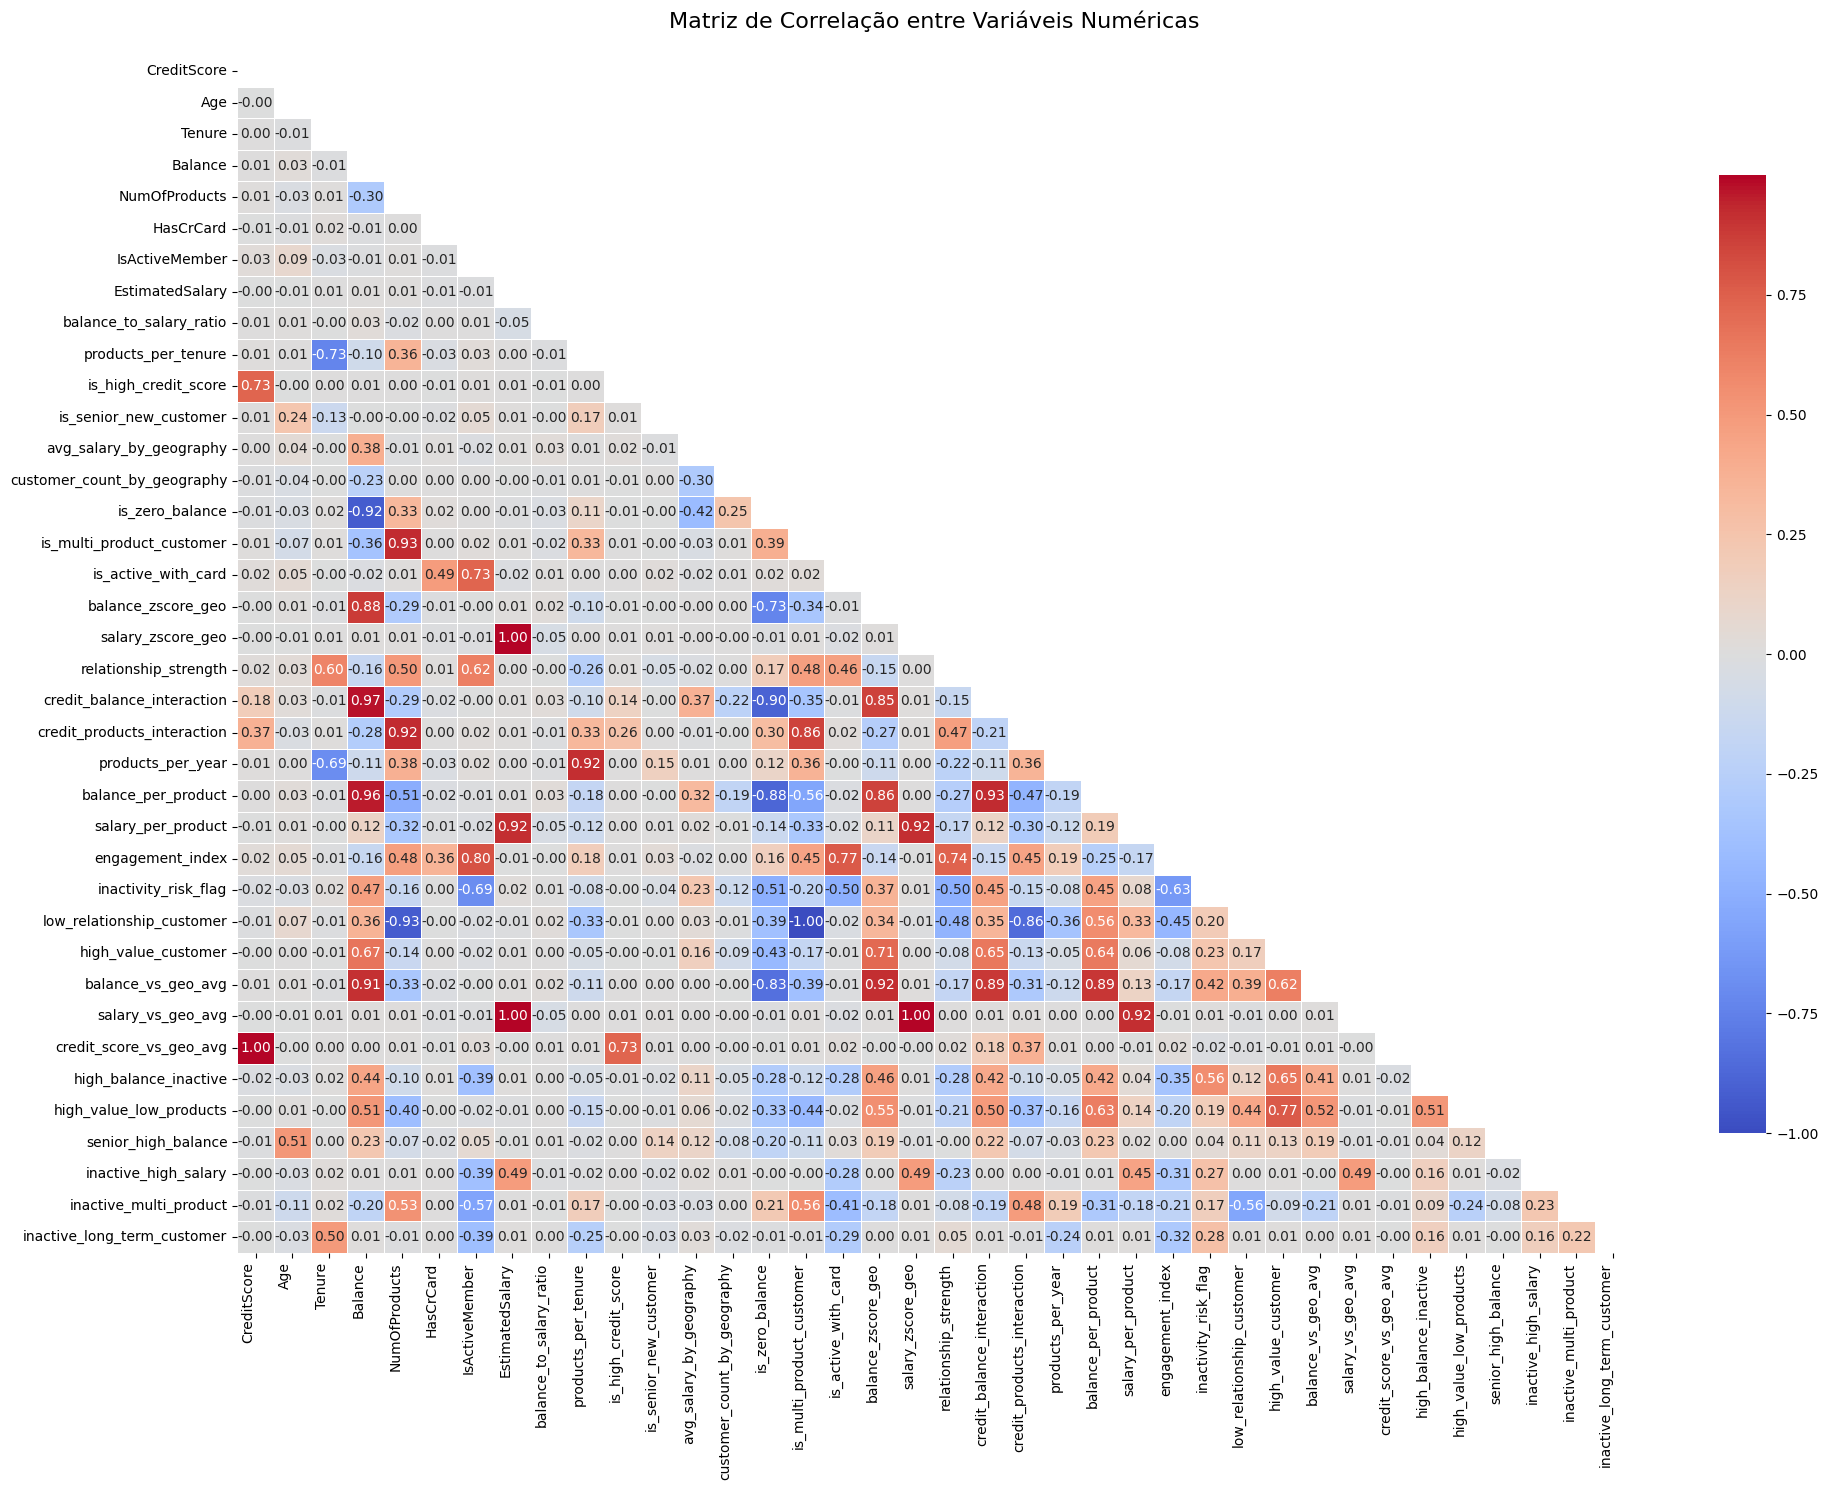

In [240]:
# Cálculo da matriz de correlação para as variáveis numéricas
correlation_matrix = X[numeric_cols].corr()

# Mantém apenas o triângulo inferior da matriz
corr = correlation_matrix.where(
    np.tril(np.ones(correlation_matrix.shape), k=-1).astype(bool))

# Criação da figura para o heatmap
plt.figure(figsize=(20, 15))

# Visualização do heatmap da matriz de correlação
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Matriz de Correlação entre Variáveis Numéricas',
    fontsize=16, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### **Variáveis mantidas**

**is_zero_balance** e **is_multi_product_customer**

Apesar da alta correlação, serão mantidas por serem variáveis binárias derivadas de variáveis originais do dataset. A feature **is_zero_balance** representa uma transformação discreta de comportamento, permitindo capturar padrões não lineares relacionados a clientes sem saldo em conta. A feature **is_multi_product_customer** representa um comportamento discreto relacionado ao engajamento do cliente com múltiplos produtos financeiros.



#### **Variáveis removidas**

**credit_balance_interaction** e **credit_products_interaction**

Serão removidas pois, além da alta correlação com as variáveis utilizadas em suas construções, as features adicionam pouca informação incremental em relação às variáveis originais.

**products_per_year**, **balance_per_product** e **salary_per_product** 

Serão removidas por representarem transformações matemáticas diretas entre variáveis originais do dataset, adicionando pouca informação nova e aumentando a redundância entre features.

**low_relationship_customer**

Será removida por representar uma discretização direta da variável **NumOfProducts**, adicionando pouca informação incremental e elevada redundância em relação à variável original.

**balance_zscore_geo** e **salary_zscore_geo**

Serão removidas por dependerem de estatísticas agregadas por grupo geográfico, tornando as features sensíveis a mudanças na distribuição populacional e potencialmente inconsistentes em ambiente de produção.

**balance_vs_geo_avg**, **salary_vs_geo_avg** e **credit_score_vs_geo_avg**

Será removida por depender de médias agregadas por grupo geográfico, introduzindo dependência contextual externa e maior sensibilidade a mudanças da distribuição populacional.

## 4. Salvando os DataFrames em formato parquet

In [241]:
# Efetuando a limpeza da memória antes do carregamento dos dados
print(f'\nQuantidade de objetos removidos da memória: {gc.collect()}')


Quantidade de objetos removidos da memória: 50359


In [242]:
# Selecionando e removendo features altamente correlacionadas 
df_final = df.drop(columns=['low_relationship_customer','balance_zscore_geo','salary_zscore_geo',
                            'balance_vs_geo_avg','salary_vs_geo_avg','credit_score_vs_geo_avg',
                            'products_per_year','balance_per_product','salary_per_product',
                            'credit_balance_interaction','credit_products_interaction'])

# Criação de data para criação de partição parquet
df_final['refined_date'] = pd.Timestamp.now().strftime('%Y-%m-%d')

# Caminho para o diretório de dados 
DATA_DIR = Path('../data/refined')

# Remove diretório antigo (overwrite)
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

# Criando diretório caso não exista
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Salvamento do dataframe em formato Parquet
try:
    df_final.to_parquet(path=DATA_DIR, engine='pyarrow',
                        partition_cols=['refined_date'],
                        compression='snappy', index=False)

    # Leitura para validação
    df_read = pd.read_parquet(DATA_DIR)
    print('VOLUMETRIA')
    print(f'Quantidade de linhas (registros):  {df_read.shape[0]:,}')
    print(f'Quantidade de colunas (variáveis): {df_read.shape[1]:,}')

except Exception as e:
    print(f'Erro ao salvar o DataFrame: {e}')

VOLUMETRIA
Quantidade de linhas (registros):  10,000
Quantidade de colunas (variáveis): 35
